# Criaturas de D&D: análise de atributos e agrupamento por semelhança

**Aluno:** Lucas Azenha  
**Abordagem:** aprendizado não supervisionado  
**Tarefa:** clusterização

## 1. O que quero investigar

Gosto de RPGs e escolhi trabalhar com criaturas de Dungeons & Dragons. Minha ideia é usar os dados do bestiário para encontrar monstros com características parecidas e entender o que aproxima ou separa essas criaturas.

A pergunta principal é: **quais criaturas têm perfis semelhantes de atributos, pontos de vida e defesa?**

Também quero verificar se os grupos encontrados têm diferenças de nível de desafio e se a análise pode ajudar a procurar alternativas para uma criatura. Um monstro parecido nos atributos não é necessariamente equivalente em combate. Ataques, magias e habilidades especiais podem mudar bastante essa comparação.

## 2. O que será feito

Vou conferir os três arquivos, preparar as variáveis e analisar a distribuição dos dados. Depois, vou testar o K-Means com diferentes quantidades de grupos e formas de escalonamento, avaliar o resultado e interpretar os grupos encontrados.

O tipo da criatura e o nível de desafio já existem nos arquivos, mas não vão definir os grupos. Se eu usasse o tipo como resposta a ser prevista, seria um problema de classificação. Aqui, a proposta é descobrir uma divisão pelas características numéricas, por isso o aprendizado é não supervisionado.

A aplicação prática é uma consulta de criaturas semelhantes. Ela serve para explorar o bestiário, sem substituir a avaliação de um mestre nem as regras de montagem de encontros.

## 3. De onde vêm os dados

Este projeto usa os três CSVs recebidos:

| Arquivo | Como será usado |
|---|---|
| `5e_monster_data_aidedd.csv` | Base principal para treinar o modelo. |
| `5e_monster_data_5eTools.csv` | Comparação dos atributos em criaturas com nomes correspondentes. |
| `5e_superceeded_monster_data_aidedd.csv` | Análise separada das versões identificadas como legacy. |

Escolhi o AideDD como base principal porque os campos usados no modelo estão completos e os nomes não se repetem. O 5eTools tem mais registros, mas também tem valores ausentes e nomes que aparecem em fontes diferentes. O arquivo legacy fica separado para não misturar versões no treinamento.

Não vou juntar os três arquivos em uma tabela única. Isso poderia repetir criaturas e dar mais peso às que aparecem em várias fontes. Também não vou substituir automaticamente valores do AideDD por valores das outras bases.

Os nomes dos CSVs indicam AideDD e 5eTools, mas a página original de publicação, a data de extração e a licença do conjunto recebido não foram informadas. Essa referência precisa ser completada quando estiver disponível. Os arquivos originais foram preservados.

## Como executar

Deixe os três CSVs na mesma pasta deste notebook. Use um ambiente Python com pandas, NumPy, Matplotlib e scikit-learn e execute as células na ordem. O arquivo `requirements.txt` registra as versões usadas nesta execução.

## 4. Bibliotecas e configurações

O pandas organiza as tabelas. O NumPy faz os cálculos numéricos. O Matplotlib gera os gráficos. O scikit-learn fornece os modelos, os escalonadores e as métricas.

Uso `random_state=42` para repetir a mesma inicialização no ambiente da execução. Também testo outras sementes mais adiante, para conferir se essa escolha altera os grupos.

In [1]:
from pathlib import Path
from fractions import Fraction
import platform
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, adjusted_rand_score

RANDOM_STATE = 42
pd.set_option("display.max_columns", 16)
pd.set_option("display.max_colwidth", 65)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titlesize": 12})
print("Python:", platform.python_version())
print({pacote: importlib.metadata.version(pacote) for pacote in ["pandas", "numpy", "matplotlib", "scikit-learn"]})

Python: 3.12.14
{'pandas': '2.2.3', 'numpy': '2.3.5', 'matplotlib': '3.10.8', 'scikit-learn': '1.8.0'}


## 5. Leitura e preparação inicial

Cada linha representa um registro de criatura. Os nomes das colunas variam entre os arquivos, então vou padronizar os campos que serão comparados.

O símbolo `-` aparece em campos sem informação numérica. Ele não será tratado como zero. Na conversão, esses valores ficam ausentes. O nível de desafio, chamado CR, tem frações como `1/4` e `1/8`; o código converte essas frações para 0,25 e 0,125.

As colunas `Unnamed: 0` e `index` são índices de exportação. Elas não descrevem a criatura e ficam fora do modelo. Uma fração de CR não tem relação com um percentual: CR 1/4 não significa 25% de dificuldade.

In [2]:
aidedd = pd.read_csv("5e_monster_data_aidedd.csv")
ferramentas = pd.read_csv("5e_monster_data_5eTools.csv")
legacy = pd.read_csv("5e_superceeded_monster_data_aidedd.csv")
ATRIBUTOS = ["str", "dex", "con", "int", "wis", "cha"]
RENOMEAR = {"Creature":"name", "Type":"type", "CR":"cr", "AC":"ac", "hp":"hp_number",
            "Size":"size", "Speed":"speed", "STR":"str", "DEX":"dex", "CON":"con",
            "INT":"int", "WIS":"wis", "CHA":"cha"}

def converter_cr(valor):
    try:
        return float(Fraction(str(valor).strip()))
    except (ValueError, ZeroDivisionError):
        return np.nan

def preparar_base(base, nomes):
    tabela = base.rename(columns=nomes).copy()
    for coluna in ["hp_number", "ac"] + ATRIBUTOS:
        tabela[coluna] = pd.to_numeric(tabela[coluna], errors="coerce")
    tabela["cr"] = tabela["cr"].map(converter_cr)
    return tabela

df = preparar_base(aidedd, RENOMEAR)
df_ferramentas = preparar_base(ferramentas, {"hp":"hp_number"})
df_legacy = preparar_base(legacy, RENOMEAR)
COLUNAS = ["name", "type", "size", "cr", "hp_number", "ac"] + ATRIBUTOS
numericas = ["hp_number", "ac"] + ATRIBUTOS
resumo = []
for nome, tabela in [("AideDD", df), ("5eTools", df_ferramentas), ("Legacy", df_legacy)]:
    resumo.append({"Base":nome, "Registros":len(tabela),
        "Nomes repetidos além do primeiro":int(tabela["name"].duplicated().sum()),
        "HP ausente":int(tabela["hp_number"].isna().sum()),
        "AC ausente":int(tabela["ac"].isna().sum()),
        "Atributos incompletos (registros)":int(tabela[ATRIBUTOS].isna().any(axis=1).sum()),
        "CR ausente":int(tabela["cr"].isna().sum())})
display(pd.DataFrame(resumo).set_index("Base"))
df[COLUNAS].head()

,Registros,Nomes repetidos além do primeiro,HP ausente,AC ausente,Atributos incompletos (registros),CR ausente
Base,,,,,,
AideDD,791,0,0,0,0,0
5eTools,2947,283,53,28,2,146
Legacy,248,0,0,0,0,0


,name,type,size,cr,hp_number,ac,str,dex,con,int,wis,cha
0,Aarakocra,humanoid (aarakocra),Medium,0.25,13,12,10,14,10,11,12,11
1,Abjurer Wizard,humanoid,Medium,9.00,104,12,9,14,14,18,12,11
2,Aboleth,aberration,Large,10.00,135,17,21,9,15,18,15,18
3,Abominable Yeti,monstrosity,Huge,9.00,137,15,24,10,22,9,13,9
4,Acererak,undead,Medium,23.00,285,21,13,16,20,27,21,20


### Conferência da base principal

Antes de treinar, preciso garantir que os nomes sejam identificáveis e que as variáveis sejam numéricas, completas e finitas. A célula interrompe a execução se encontrar um problema nesses campos. Nenhuma criatura será excluída silenciosamente da base principal.

In [3]:
if df["name"].isna().any() or df["name"].duplicated().any():
    raise ValueError("Revise os nomes da base principal.")
if df[numericas].isna().any().any() or not np.isfinite(df[numericas].to_numpy()).all():
    raise ValueError("Há variáveis ausentes ou inválidas na base principal.")
if (df["hp_number"] < 0).any() or (df[ATRIBUTOS] <= 0).any().any():
    raise ValueError("Há valores fora da faixa esperada.")
print("Criaturas mantidas na base principal:", len(df))
print("Colunas de índice do CSV não entram no modelo.")
df[numericas].describe().round(2)

Criaturas mantidas na base principal: 791
Colunas de índice do CSV não entram no modelo.


,hp_number,ac,str,dex,con,int,wis,cha
count,791.00,791.00,791.00,791.00,791.00,791.00,791.00,791.00
mean,95.97,14.76,15.33,13.30,15.64,9.95,12.41,11.25
std,100.70,3.16,6.27,3.38,4.43,6.09,3.49,5.89
min,1.00,5.00,1.00,1.00,3.00,1.00,1.00,1.00
25%,26.00,12.00,11.00,11.00,12.00,5.00,10.00,7.00
50%,65.00,15.00,16.00,14.00,15.00,10.00,12.00,11.00
75%,135.50,17.00,19.00,15.00,18.00,14.00,14.00,16.00
max,676.00,25.00,30.00,28.00,30.00,30.00,27.00,30.00


In [4]:
auditoria = []
for nome, tabela in [("AideDD", df), ("5eTools", df_ferramentas), ("Legacy", df_legacy)]:
    for campo in ["hp_number", "ac"] + ATRIBUTOS + ["cr"]:
        auditoria.append({"Base":nome, "Campo":campo, "Ausentes após conversão":int(tabela[campo].isna().sum())})
pd.DataFrame(auditoria).pivot(index="Campo", columns="Base", values="Ausentes após conversão")

Base,5eTools,AideDD,Legacy
Campo,,,
ac,28,0,0
cha,2,0,0
con,2,0,0
cr,146,0,0
dex,2,0,0
hp_number,53,0,0
int,2,0,0
str,2,0,0
wis,2,0,0


## 6. Entendendo a base antes do modelo

Vou olhar a distribuição de HP, classe de armadura e atributos. O objetivo é perceber se existem valores extremos e diferenças de escala que possam influenciar o K-Means.

Uma criatura com muitos pontos de vida pode ficar distante das outras só por esse número. Por isso, essa coluna precisa de atenção na preparação.

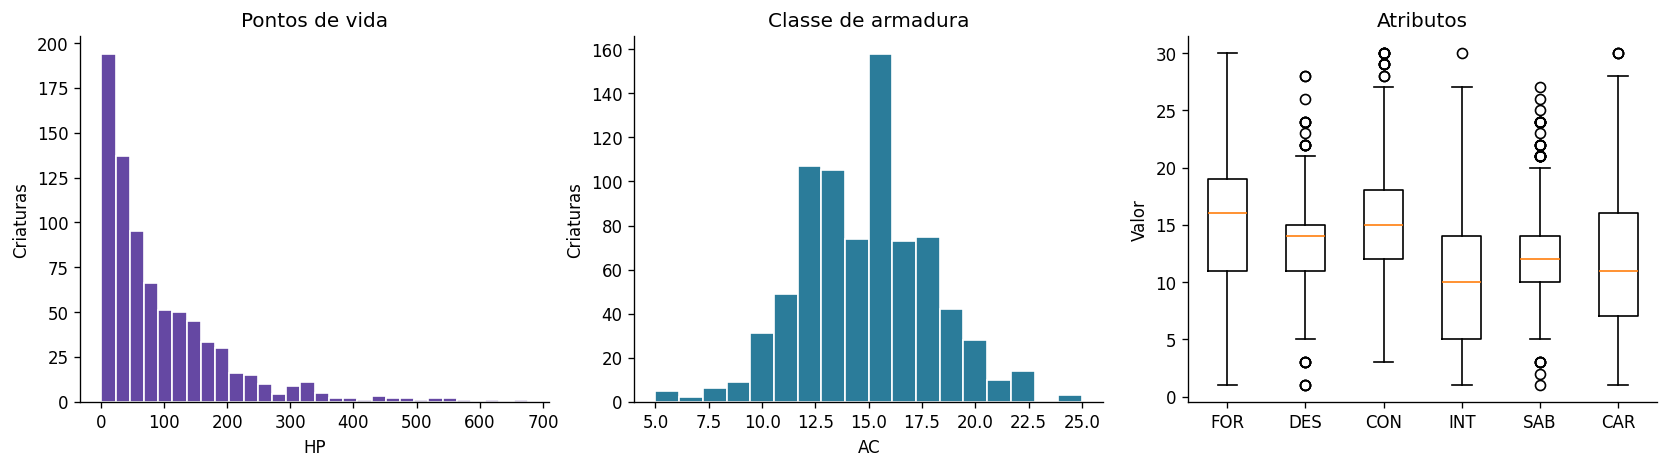

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(df["hp_number"], bins=30, color="#6548a3", edgecolor="white")
axes[0].set(title="Pontos de vida", xlabel="HP", ylabel="Criaturas")
axes[1].hist(df["ac"], bins=18, color="#2b7c9a", edgecolor="white")
axes[1].set(title="Classe de armadura", xlabel="AC", ylabel="Criaturas")
axes[2].boxplot([df[c] for c in ATRIBUTOS], labels=["FOR", "DES", "CON", "INT", "SAB", "CAR"])
axes[2].set(title="Atributos", ylabel="Valor")
fig.tight_layout()
plt.show()

### Tipos, tamanho e nível de desafio

Essas informações ajudam a entender quais criaturas estão representadas. O campo de tipo às vezes inclui um subtipo entre parênteses. Para fazer uma contagem mais legível, vou separar apenas o texto anterior ao parêntese, sem modificar o campo original.

A frequência de um tipo depende do conteúdo desta base. Ela não representa a frequência desse tipo em todas as campanhas de D&D.

In [6]:
df["tipo_base"] = df["type"].str.split("(", regex=False).str[0].str.strip().str.casefold()
display(df["tipo_base"].value_counts().rename_axis("Tipo").to_frame("Criaturas"))
display(df["size"].value_counts().rename_axis("Tamanho").to_frame("Criaturas"))
df["cr"].describe().round(2)

,Criaturas
Tipo,
humanoid,152
beast,108
monstrosity,98
fiend,90
dragon,79
undead,54
elemental,44
aberration,42
giant,27


,Criaturas
Tamanho,
Medium,373
Large,205
Huge,77
Small,59
Tiny,41
Gargantuan,36


count    791.00
mean       6.04
std        6.52
min        0.00
25%        1.00
50%        4.00
75%        9.00
max       30.00
Name: cr, dtype: float64

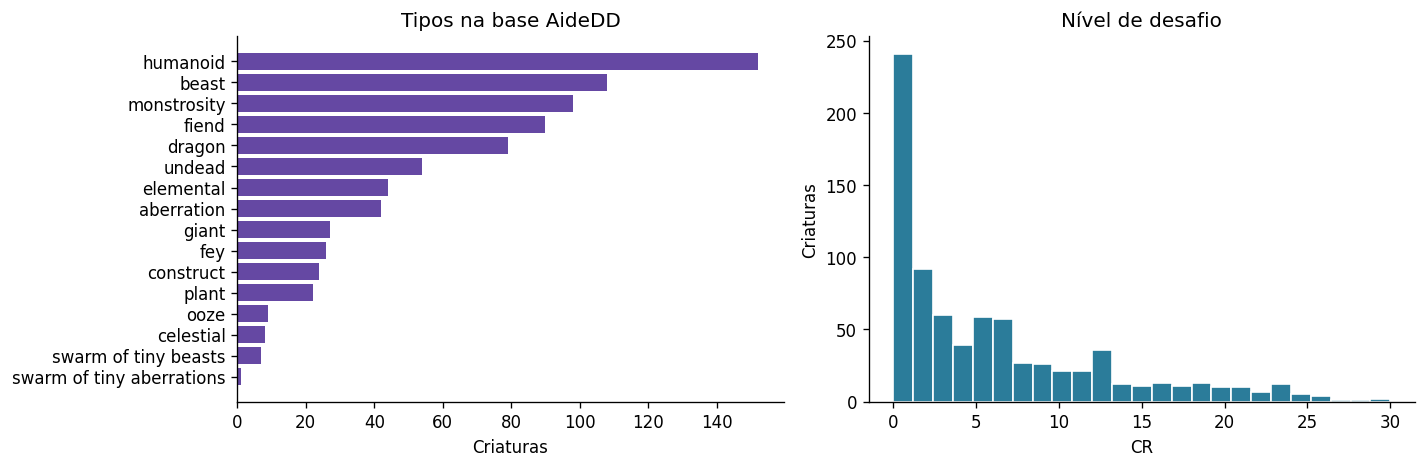

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
contagens = df["tipo_base"].value_counts().sort_values()
axes[0].barh(contagens.index, contagens.values, color="#6548a3")
axes[0].set(title="Tipos na base AideDD", xlabel="Criaturas")
axes[1].hist(df["cr"].dropna(), bins=25, color="#2b7c9a", edgecolor="white")
axes[1].set(title="Nível de desafio", xlabel="CR", ylabel="Criaturas")
fig.tight_layout()
plt.show()

## 7. Quais variáveis entram no modelo

| Variável | O que representa | Tratamento |
|---|---|---|
| STR, DEX, CON | Força, destreza e constituição | Mantidas como valores numéricos. |
| INT, WIS, CHA | Inteligência, sabedoria e carisma | Mantidas como valores numéricos. |
| AC | Classe de armadura | Mantida como valor numérico. |
| HP | Pontos de vida | Transformação `log1p`, depois escalonamento. |

O modelo usa oito variáveis. Nome, tipo, tamanho, CR e movimento ficam fora do treinamento. Esses campos ajudam a descrever o resultado depois.

A transformação `log1p` calcula o logaritmo de `1 + HP`. Ela reduz a diferença entre valores muito altos e os demais, sem inverter a ordem: uma criatura com mais HP continua com um valor transformado maior.

Não vou incluir os bônus de testes de resistência neste primeiro modelo. Eles têm campos não preenchidos e não são informações totalmente independentes dos atributos. A coluna Speed do AideDD indica modalidades como voo e natação, não uma velocidade numérica.

In [8]:
X = df[ATRIBUTOS + ["ac"]].astype(float).copy()
X["log_hp"] = np.log1p(df["hp_number"])
FEATURES = X.columns.tolist()
print("Matriz usada no modelo:", X.shape)
X.head().round(3)

Matriz usada no modelo: (791, 8)


,str,dex,con,int,wis,cha,ac,log_hp
0,10.0,14.0,10.0,11.0,12.0,11.0,12.0,2.639
1,9.0,14.0,14.0,18.0,12.0,11.0,12.0,4.654
2,21.0,9.0,15.0,18.0,15.0,18.0,17.0,4.913
3,24.0,10.0,22.0,9.0,13.0,9.0,15.0,4.927
4,13.0,16.0,20.0,27.0,21.0,20.0,21.0,5.656


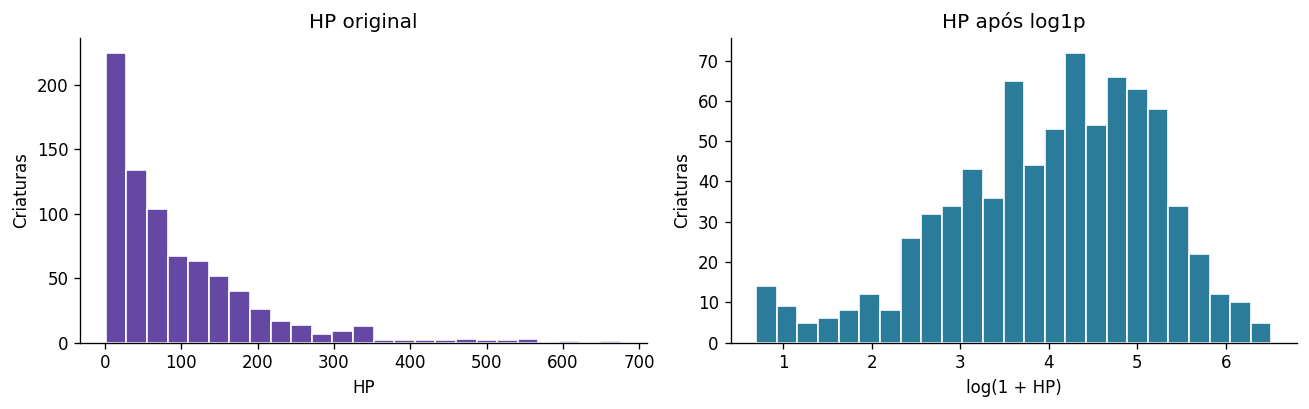

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df["hp_number"], bins=25, color="#6548a3", edgecolor="white")
axes[0].set(title="HP original", xlabel="HP", ylabel="Criaturas")
axes[1].hist(X["log_hp"], bins=25, color="#2b7c9a", edgecolor="white")
axes[1].set(title="HP após log1p", xlabel="log(1 + HP)", ylabel="Criaturas")
fig.tight_layout()
plt.show()

### Relações entre as variáveis

A matriz de correlação mostra quais variáveis variam juntas. Ela não demonstra que uma causa a outra. Se duas colunas são muito relacionadas, ambas podem reforçar uma mesma característica no cálculo das distâncias.

Vou manter os seis atributos, AC e HP transformado por serem parte da descrição escolhida. Isso não torna a seleção neutra: a composição das variáveis influencia os grupos. Mais adiante, testo o modelo sem HP para observar o efeito dessa decisão.

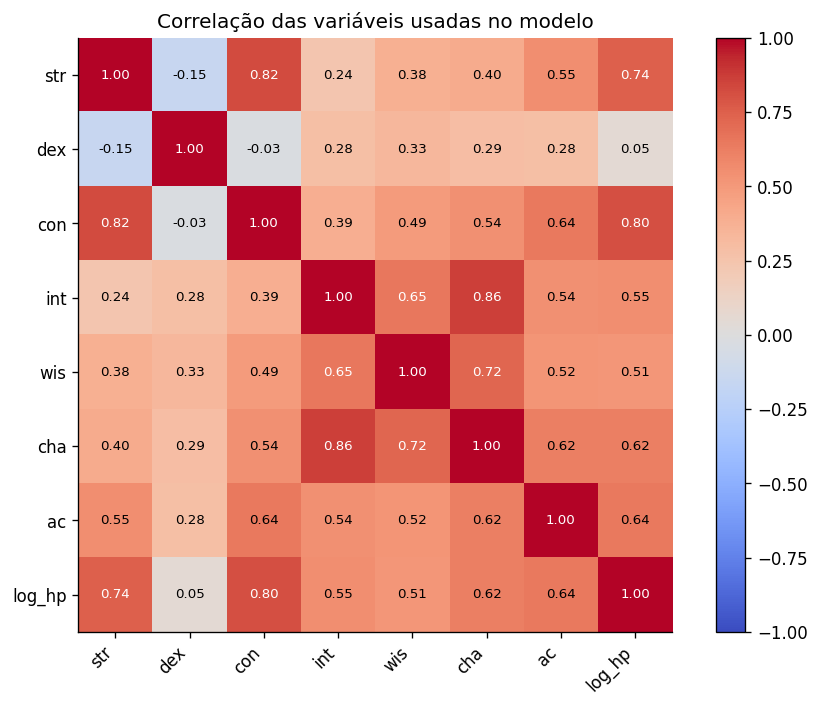

In [10]:
correlacao = X.corr()
fig, ax = plt.subplots(figsize=(8, 6))
imagem = ax.imshow(correlacao, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURES)), FEATURES)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        valor = correlacao.iloc[i, j]
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(valor) > 0.65 else "black")
ax.set_title("Correlação das variáveis usadas no modelo")
fig.colorbar(imagem, ax=ax, fraction=0.045)
fig.tight_layout()
plt.show()

## 8. Escalonamento e quantidade de grupos

O K-Means aproxima cada criatura do centro mais próximo e ajusta esses centros para reduzir as distâncias quadráticas dentro dos grupos. Eu preciso informar quantos grupos quero testar. O algoritmo não escolhe esse número sozinho.

Antes disso, as variáveis precisam de escalonamento. Caso contrário, suas diferentes escalas podem pesar na comparação.

| Escalonador | O que faz |
|---|---|
| StandardScaler | Usa a média e o desvio-padrão de cada variável. |
| RobustScaler | Usa a mediana e o intervalo entre o primeiro e o terceiro quartil. |
| MinMaxScaler | Coloca cada variável entre 0 e 1 na base usada no ajuste. |

Nenhum deles elimina os problemas com valores extremos. Vou testar os três, com dois a dez grupos e vinte inicializações por solução.

### Como vou avaliar

- **Silhueta:** compara a distância média da criatura ao próprio grupo com a distância média ao grupo vizinho. Quanto maior, melhor a separação média.
- **Davies-Bouldin:** relaciona a dispersão interna à separação dos centros. Quanto menor, melhor nesse critério.
- **Inércia:** soma das distâncias quadráticas aos centros. Ela tende a cair quando aumento a quantidade de grupos; o gráfico ajuda a observar o ritmo dessa queda.
- **Tamanho dos grupos:** permite perceber se o modelo isolou uma única criatura ou concentrou quase toda a base em um grupo.

A regra de escolha é a maior silhueta entre soluções sem grupos de uma única criatura. Em caso de empate, prefiro menos grupos. Davies-Bouldin, inércia e tamanho dos grupos ficam como verificações complementares.

As métricas de escalonadores diferentes são calculadas em espaços diferentes. Essa comparação é exploratória, não uma prova de que um escalonador é superior em qualquer situação.

Esta é uma análise exploratória de toda a base, sem previsão de uma variável-alvo. Não vou tratar a silhueta como acurácia nem criar uma divisão aleatória de treino e teste só para reproduzir um fluxo de classificação. A estabilidade será verificada por outras inicializações e por mudanças no modelo.

In [11]:
SCALERS = {"StandardScaler": StandardScaler(), "RobustScaler": RobustScaler(), "MinMaxScaler": MinMaxScaler()}
resultados = []
for nome, escalonador in SCALERS.items():
    dados = escalonador.fit_transform(X)
    for k in range(2, 11):
        modelo = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(dados)
        tamanhos = np.bincount(modelo.labels_)
        resultados.append({"Scaler":nome, "k":k,
            "Silhueta":silhouette_score(dados, modelo.labels_),
            "Davies-Bouldin":davies_bouldin_score(dados, modelo.labels_),
            "Inércia":modelo.inertia_, "Menor grupo":int(tamanhos.min()),
            "Maior grupo":int(tamanhos.max()), "Tamanhos":sorted(tamanhos.tolist())})
metricas = pd.DataFrame(resultados)
elegiveis = metricas[metricas["Menor grupo"] >= 2]
if elegiveis.empty:
    raise ValueError("Nenhuma solução atende à regra definida.")
escolha = elegiveis.sort_values(["Silhueta", "k", "Scaler"], ascending=[False, True, True]).iloc[0]
SCALER_ESCOLHIDO = escolha["Scaler"]
K_ESCOLHIDO = int(escolha["k"])
print("Solução selecionada:", SCALER_ESCOLHIDO, "com", K_ESCOLHIDO, "grupos")
metricas.round(3)

Solução selecionada: MinMaxScaler com 2 grupos


,Scaler,k,Silhueta,Davies-Bouldin,Inércia,Menor grupo,Maior grupo,Tamanhos
0,StandardScaler,2,0.322,1.185,4050.892,262,529,"[262, 529]"
1,StandardScaler,3,0.217,1.466,3356.652,156,371,"[156, 264, 371]"
2,StandardScaler,4,0.221,1.331,2876.680,136,252,"[136, 178, 225, 252]"
3,StandardScaler,5,0.206,1.372,2601.079,70,217,"[70, 162, 168, 174, 217]"
4,StandardScaler,6,0.198,1.372,2390.658,66,194,"[66, 110, 127, 145, 149, 194]"
5,StandardScaler,7,0.190,1.386,2247.597,36,183,"[36, 69, 111, 117, 124, 151, 183]"
6,StandardScaler,8,0.184,1.438,2127.587,36,160,"[36, 76, 77, 78, 86, 139, 139, 160]"
7,StandardScaler,9,0.191,1.360,1999.731,20,155,"[20, 33, 72, 73, 77, 83, 137, 141, 155]"
8,StandardScaler,10,0.182,1.395,1918.706,17,132,"[17, 22, 45, 69, 79, 81, 91, 126, 129, 132]"
9,RobustScaler,2,0.310,1.238,2321.527,260,531,"[260, 531]"


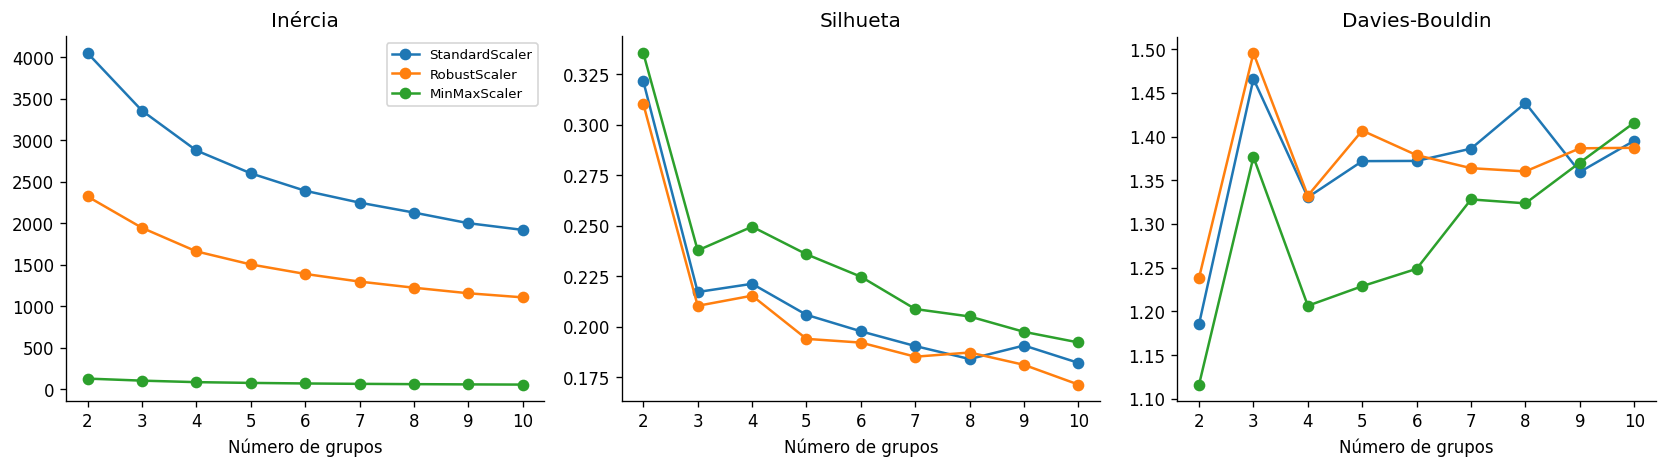

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for nome in SCALERS:
    tabela = metricas[metricas["Scaler"] == nome]
    for ax, coluna in zip(axes, ["Inércia", "Silhueta", "Davies-Bouldin"]):
        ax.plot(tabela["k"], tabela[coluna], marker="o", label=nome)
        ax.set(title=coluna, xlabel="Número de grupos", xticks=range(2, 11))
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

### Leitura da escolha

A célula seguinte mostra a melhor solução de cada escalonador pela regra definida. Se dois grupos forem escolhidos, vou interpretar essa divisão ampla. Não vou aumentar o número só para obter nomes que parecem mais interessantes, como tanques ou conjuradores.

In [13]:
melhores = elegiveis.sort_values(["Silhueta", "k"], ascending=[False, True]).groupby("Scaler", sort=False).head(1)
display(melhores[["Scaler", "k", "Silhueta", "Davies-Bouldin", "Menor grupo", "Maior grupo"]].round(3))
print(f"Escolha final: k={K_ESCOLHIDO}; silhueta={escolha['Silhueta']:.3f}; Davies-Bouldin={escolha['Davies-Bouldin']:.3f}.")

Escolha final: k=2; silhueta=0.336; Davies-Bouldin=1.116.


,Scaler,k,Silhueta,Davies-Bouldin,Menor grupo,Maior grupo
18,MinMaxScaler,2,0.336,1.116,263,528
0,StandardScaler,2,0.322,1.185,262,529
9,RobustScaler,2,0.310,1.238,260,531


## 9. Modelo final

Agora ajusto o escalonador escolhido e treino o K-Means nas oito variáveis. Os números dos grupos são apenas identificadores. Grupo 1 não significa mais forte, melhor ou mais difícil que Grupo 2.

Também calculo a silhueta de cada criatura. Uma silhueta negativa indica que a distância média a algum outro grupo é menor que a distância média ao grupo atual. Isso merece atenção, mas não obriga a trocar a criatura de grupo manualmente.

In [14]:
scaler = SCALERS[SCALER_ESCOLHIDO]
X_escalonado = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=K_ESCOLHIDO, n_init=20, random_state=RANDOM_STATE)
rotulos = kmeans.fit_predict(X_escalonado)
resultado = df[COLUNAS].copy()
resultado["Grupo"] = rotulos + 1
resultado["Silhueta"] = silhouette_samples(X_escalonado, rotulos)
print("Silhueta geral:", round(silhouette_score(X_escalonado, rotulos), 3))
print("Davies-Bouldin:", round(davies_bouldin_score(X_escalonado, rotulos), 3))
resultado.groupby("Grupo").agg(Criaturas=("name", "count"),
    Silhueta_media=("Silhueta", "mean"), Silhuetas_negativas=("Silhueta", lambda s: int((s < 0).sum()))).round(3)

Silhueta geral: 0.336
Davies-Bouldin: 1.116


,Criaturas,Silhueta_media,Silhuetas_negativas
Grupo,,,
1,263,0.316,2
2,528,0.345,0


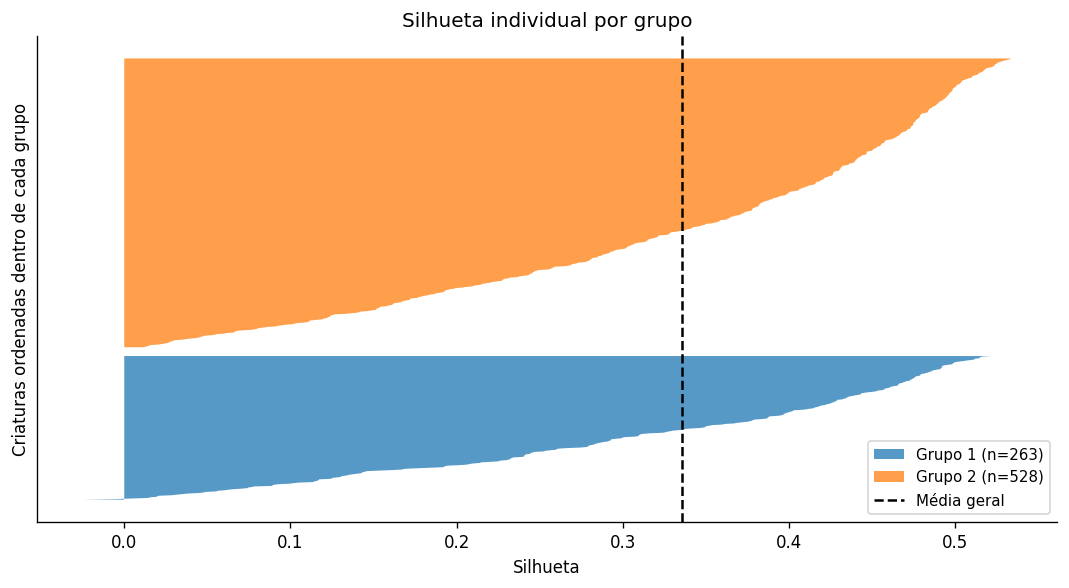

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
inicio = 0
for grupo in sorted(resultado["Grupo"].unique()):
    valores = np.sort(resultado.loc[resultado["Grupo"] == grupo, "Silhueta"].to_numpy())
    posicoes = np.arange(inicio, inicio + len(valores))
    ax.fill_betweenx(posicoes, 0, valores, alpha=0.75, label=f"Grupo {grupo} (n={len(valores)})")
    inicio += len(valores) + 15
ax.axvline(silhouette_score(X_escalonado, rotulos), color="black", linestyle="--", label="Média geral")
ax.set(title="Silhueta individual por grupo", xlabel="Silhueta", ylabel="Criaturas ordenadas dentro de cada grupo", yticks=[])
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 10. O que caracteriza cada grupo

Uso a mediana para resumir os atributos, pois ela sofre menos influência de valores extremos. Esses valores estão nas unidades originais. HP aparece como pontos de vida, e não como logaritmo.

O CR entra nesta tabela apenas para descrever os grupos. Uma diferença de CR depois do treinamento pode ajudar a interpretar o resultado, mas não torna o modelo uma previsão de dificuldade.

In [16]:
perfil = resultado.groupby("Grupo")[["hp_number", "ac"] + ATRIBUTOS + ["cr"]].median()
perfil.insert(0, "Quantidade", resultado.groupby("Grupo").size())
perfil.rename(columns={"hp_number":"HP", "ac":"AC", "str":"FOR", "dex":"DES", "con":"CON",
                       "int":"INT", "wis":"SAB", "cha":"CAR", "cr":"CR"}).round(2)

,Quantidade,HP,AC,FOR,DES,CON,INT,SAB,CAR,CR
Grupo,,,,,,,,,,
1,263,162.0,18.0,20.0,14.0,19.0,16.0,15.0,17.0,12.0
2,528,36.0,13.0,14.0,13.0,13.0,7.0,11.0,8.0,2.0


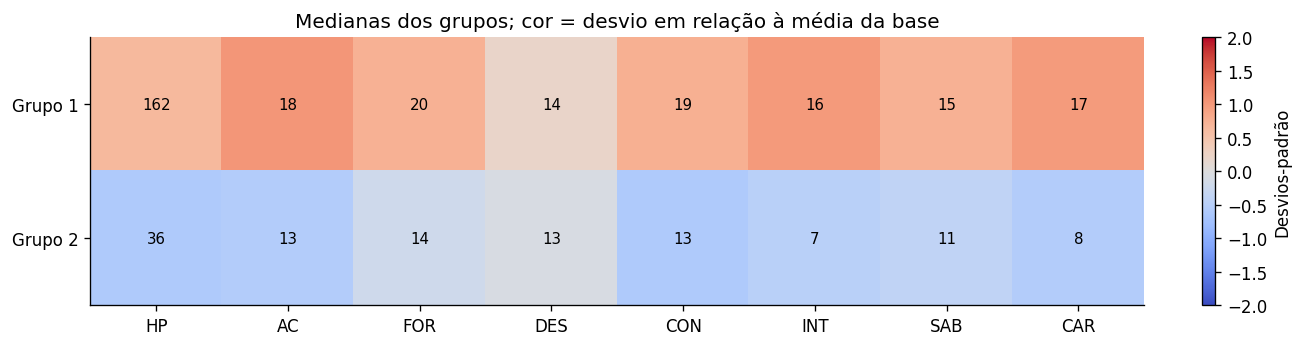

In [17]:
perfil_visual = perfil[["hp_number", "ac"] + ATRIBUTOS]
referencia = df[["hp_number", "ac"] + ATRIBUTOS]
desvios = referencia.std().replace(0, 1)
cores = (perfil_visual - referencia.mean()) / desvios
fig, ax = plt.subplots(figsize=(11, max(3, K_ESCOLHIDO * 0.6)))
imagem = ax.imshow(cores, cmap="coolwarm", vmin=-2, vmax=2, aspect="auto")
nomes_colunas = ["HP", "AC", "FOR", "DES", "CON", "INT", "SAB", "CAR"]
ax.set_xticks(range(8), nomes_colunas)
ax.set_yticks(range(K_ESCOLHIDO), [f"Grupo {g}" for g in perfil.index])
for i in range(K_ESCOLHIDO):
    for j in range(8):
        ax.text(j, i, f"{perfil_visual.iloc[i, j]:g}", ha="center", va="center", fontsize=9,
                color="white" if abs(cores.iloc[i, j]) > 1.3 else "black")
ax.set_title("Medianas dos grupos; cor = desvio em relação à média da base")
fig.colorbar(imagem, ax=ax, label="Desvios-padrão", fraction=0.035)
fig.tight_layout()
plt.show()

No mapa, a cor compara a mediana do grupo com a média da base em unidades de desvio-padrão. Os números são as medianas reais. Essa escala de cores é só uma escolha de visualização, diferente do escalonamento que pode ter sido selecionado para o modelo.

A seguir, mostro criaturas próximas dos centros. São exemplos representativos das variáveis usadas, não uma lista das criaturas mais famosas ou mais fortes.

In [18]:
for grupo in sorted(resultado["Grupo"].unique()):
    membros = resultado[resultado["Grupo"] == grupo]
    print(f"\nGrupo {grupo}: {len(membros)} criaturas")
    print("Tipos mais frequentes:", membros["type"].value_counts().head(3).to_dict())
    print("Exemplos próximos do centro:")
    distancias = np.linalg.norm(X_escalonado[membros.index] - kmeans.cluster_centers_[grupo - 1], axis=1)
    exemplos = membros.assign(Distancia=distancias).nsmallest(5, "Distancia")
    print(exemplos[["name", "type", "cr", "hp_number"]].to_string(index=False))


Grupo 1: 263 criaturas
Tipos mais frequentes: {'fiend (demon)': 23, 'dragon (gem)': 18, 'fiend (devil)': 18}
Exemplos próximos do centro:
                 name             type   cr  hp_number
Young Sapphire Dragon     dragon (gem)  9.0        157
            Yagnoloth fiend (yugoloth) 11.0        147
    Adult Deep Dragon           dragon 11.0        147
              Nabassu    fiend (demon) 15.0        190
            Ice Devil    fiend (devil) 14.0        180

Grupo 2: 528 criaturas
Tipos mais frequentes: {'beast': 103, 'monstrosity': 71, 'undead': 31}
Exemplos próximos do centro:
              name        type  cr  hp_number
   Vegepygmy Chief       plant 2.0         33
              Worg monstrosity 0.5         26
          Ettercap monstrosity 2.0         44
      Gnoll Hunter monstrosity 0.5         22
Gnoll Flesh Gnawer monstrosity 1.0         22


In [19]:
resultado["tipo_base"] = df["tipo_base"]
resultado["Voa"] = df["speed"].fillna("").str.contains("fly", case=False, regex=False)
resultado["Nada"] = df["speed"].fillna("").str.contains("swim", case=False, regex=False)
display(pd.crosstab(resultado["Grupo"], resultado["tipo_base"]))
display(pd.crosstab(resultado["Grupo"], resultado["size"]))
resultado.groupby("Grupo").agg(Criaturas=("name", "count"),
    Percentual_com_voo=("Voa", lambda s: s.mean() * 100),
    Percentual_com_natacao=("Nada", lambda s: s.mean() * 100)).round(1)

tipo_base,aberration,beast,celestial,construct,dragon,elemental,fey,fiend,giant,humanoid,monstrosity,ooze,plant,swarm of tiny aberrations,swarm of tiny beasts,undead
Grupo,,,,,,,,,,,,,,,,
1,13,0,7,2,62,14,9,56,12,41,23,2,2,0,0,20
2,29,108,1,22,17,30,17,34,15,111,75,7,20,1,7,34


size,Gargantuan,Huge,Large,Medium,Small,Tiny
Grupo,,,,,,
1,34,53,73,101,1,1
2,2,24,132,272,58,40


,Criaturas,Percentual_com_voo,Percentual_com_natacao
Grupo,,,
1,263,47.1,18.3
2,528,18.6,12.7


Esses percentuais indicam quantas criaturas têm `fly` ou `swim` registrados no campo Speed. Não medem velocidade. Quando o arquivo usa `-`, não concluo que a criatura tenha velocidade zero.

## 11. Visualização com PCA

A PCA projeta as oito variáveis em dois eixos. Ela é usada só para o gráfico. O K-Means continua treinado nas oito variáveis escalonadas.

A variância explicada indica quanto da variação fica representado nesses dois eixos. Duas criaturas próximas na imagem podem ter diferenças nas dimensões que não aparecem nela.

Variância explicada pelos dois eixos: 81.0%


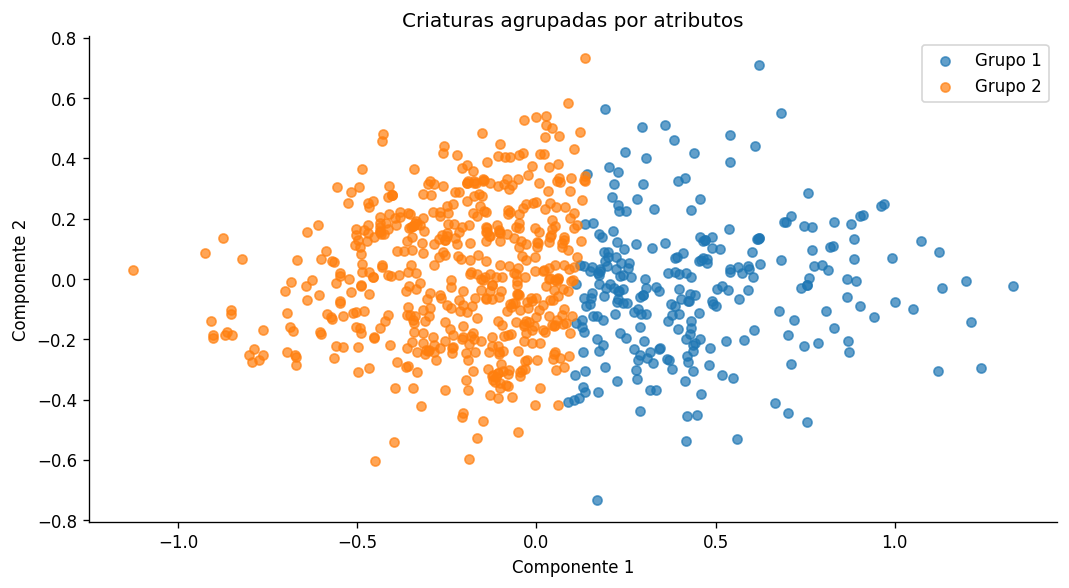

In [20]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_escalonado)
print("Variância explicada pelos dois eixos:", f"{pca.explained_variance_ratio_.sum():.1%}")
fig, ax = plt.subplots(figsize=(9, 5))
for grupo in sorted(resultado["Grupo"].unique()):
    mask = resultado["Grupo"].eq(grupo).to_numpy()
    ax.scatter(coords[mask, 0], coords[mask, 1], s=30, alpha=0.7, label=f"Grupo {grupo}")
ax.set(title="Criaturas agrupadas por atributos", xlabel="Componente 1", ylabel="Componente 2")
ax.legend()
fig.tight_layout()
plt.show()

In [21]:
pd.DataFrame(pca.components_.T, index=FEATURES, columns=["Peso no componente 1", "Peso no componente 2"]).round(3)

,Peso no componente 1,Peso no componente 2
str,0.405,0.582
dex,0.057,-0.280
con,0.342,0.299
int,0.404,-0.525
wis,0.245,-0.178
cha,0.438,-0.373
ac,0.313,-0.000
log_hp,0.450,0.216


## 12. O resultado muda com outra inicialização?

Repito o K-Means com dez sementes, mantendo a quantidade de grupos e vinte inicializações por execução. Comparo as divisões pelo Adjusted Rand Index, ou ARI.

ARI igual a 1 significa a mesma divisão, mesmo que os números dos grupos mudem. Valores menores indicam diferenças. Esse teste avalia a inicialização; não prova estabilidade em outros bestiários ou em outras variáveis.

In [22]:
estabilidade = []
for semente in range(10):
    outros = KMeans(n_clusters=K_ESCOLHIDO, n_init=20, random_state=semente).fit_predict(X_escalonado)
    estabilidade.append(adjusted_rand_score(rotulos, outros))
print("ARI mínimo:", round(min(estabilidade), 3))
print("ARI médio:", round(float(np.mean(estabilidade)), 3))
pd.DataFrame({"Semente":range(10), "ARI em relação ao modelo final":estabilidade}).round(3)

ARI mínimo: 0.94
ARI médio: 0.964


,Semente,ARI em relação ao modelo final
0,0,0.94
1,1,0.94
2,2,0.97
3,3,0.94
4,4,1.00
5,5,0.97
6,6,0.97
7,7,0.97
8,8,0.97
9,9,0.97


## 13. Duas verificações adicionais

### Retirando os pontos de vida

A relação com HP pode pesar na divisão. Vou retirar essa coluna, manter os seis atributos e AC e treinar com o mesmo escalonador e a mesma quantidade de grupos. O ARI mostra quanto essa mudança altera a divisão.

As silhuetas são calculadas em espaços com variáveis diferentes. Por isso, uma silhueta maior neste teste não basta para dizer que excluir HP melhora o projeto.

### Comparando outro algoritmo

Também vou usar agrupamento hierárquico aglomerativo com ligação Ward. Ele começa com cada criatura em um grupo e faz junções sucessivas. A comparação usa as mesmas oito variáveis escalonadas e o mesmo número de grupos.

A ideia é conferir o quanto a divisão depende do K-Means, sem escolher um novo modelo apenas porque uma métrica ficou maior.

In [23]:
X_sem_hp = X.drop(columns="log_hp")
escalonador_sem_hp = type(scaler)()
dados_sem_hp = escalonador_sem_hp.fit_transform(X_sem_hp)
rotulos_sem_hp = KMeans(n_clusters=K_ESCOLHIDO, n_init=20, random_state=RANDOM_STATE).fit_predict(dados_sem_hp)
rotulos_hierarquicos = AgglomerativeClustering(n_clusters=K_ESCOLHIDO, linkage="ward").fit_predict(X_escalonado)
verificacoes = pd.DataFrame([
    {"Modelo":"K-Means principal", "Variáveis":8,
     "Silhueta":silhouette_score(X_escalonado, rotulos), "ARI com principal":1.0},
    {"Modelo":"K-Means sem HP", "Variáveis":7,
     "Silhueta":silhouette_score(dados_sem_hp, rotulos_sem_hp),
     "ARI com principal":adjusted_rand_score(rotulos, rotulos_sem_hp)},
    {"Modelo":"Hierárquico Ward", "Variáveis":8,
     "Silhueta":silhouette_score(X_escalonado, rotulos_hierarquicos),
     "ARI com principal":adjusted_rand_score(rotulos, rotulos_hierarquicos)}])
verificacoes.round(3)

,Modelo,Variáveis,Silhueta,ARI com principal
0,K-Means principal,8,0.336,1.000
1,K-Means sem HP,7,0.339,0.934
2,Hierárquico Ward,8,0.290,0.677


## 14. Consulta de criaturas semelhantes

Agora a análise vira uma consulta: escolho uma criatura e o código procura as mais próximas nas oito variáveis escalonadas. A busca considera toda a base, mesmo quando a criatura está em outro grupo.

Distância menor significa maior semelhança nesses critérios. Não significa que duas criaturas tenham os mesmos ataques ou possam substituir uma à outra sem ajustar o encontro. Nome e CR são mostrados para conferir o resultado, mas não entram na distância.

In [24]:
def semelhantes(nome, quantidade=5):
    if not isinstance(quantidade, int) or isinstance(quantidade, bool) or quantidade < 1:
        raise ValueError("A quantidade precisa ser um inteiro positivo.")
    encontrados = resultado.index[resultado["name"].str.strip().str.casefold().eq(nome.strip().casefold())]
    if len(encontrados) != 1:
        raise ValueError("Nome não encontrado. Consulte a coluna name da base principal.")
    indice = encontrados[0]
    distancias = np.linalg.norm(X_escalonado - X_escalonado[indice], axis=1)
    consulta = resultado.copy()
    consulta["Distancia"] = distancias
    return consulta.drop(index=indice).nsmallest(quantidade, "Distancia")[["name", "type", "Grupo", "cr", "hp_number", "ac", "Distancia"]]

# Troque o nome abaixo para explorar outra criatura.
semelhantes("Aboleth", quantidade=5).round(3)

,name,type,Grupo,cr,hp_number,ac,Distancia
491,Muiral,monstrosity,1,13.0,195,16,0.155
32,Amethyst Dragon Wyrmling,dragon (gem),1,4.0,75,17,0.183
502,Narzugon,fiend (devil),1,13.0,112,20,0.197
777,Young Topaz Dragon,dragon (gem),1,7.0,127,17,0.202
60,Arcanaloth,fiend (yugoloth),1,12.0,104,17,0.205


## 15. Conferência entre AideDD e 5eTools

Vou comparar nomes correspondentes depois de padronizar letras e espaços. No 5eTools, alguns nomes aparecem mais de uma vez em fontes diferentes. Não escolho uma dessas versões de forma arbitrária: nomes ambíguos ficam fora da comparação.

Essa é uma comparação conservadora. Ela não relaciona nomes diferentes da mesma criatura. Uma diferença de HP ou AC pode vir de versão, edição ou extração diferente; não comprova erro de uma fonte.

In [25]:
def chave_nome(serie):
    return serie.astype("string").str.strip().str.casefold().str.replace(r"\s+", " ", regex=True)

principal = df.assign(chave=chave_nome(df["name"]))
outra = df_ferramentas.assign(chave=chave_nome(df_ferramentas["name"]))
if principal["chave"].duplicated().any():
    raise ValueError("Há nomes ambíguos na base principal após padronizar.")
ambigua = outra["chave"].duplicated(keep=False)
comparacao = principal.merge(outra.loc[~ambigua], on="chave", suffixes=("_aidedd", "_5etools"), validate="one_to_one")
campos = ["hp_number", "ac"] + ATRIBUTOS + ["cr"]
conferencia = []
for campo in campos:
    a, b = comparacao[campo + "_aidedd"], comparacao[campo + "_5etools"]
    validos = a.notna() & b.notna()
    diferentes = validos & ~np.isclose(a, b, equal_nan=False)
    conferencia.append({"Campo":campo, "Pares comparáveis":int(validos.sum()),
        "Valores diferentes":int(diferentes.sum()), "Pares incompletos":int((~validos).sum())})
print("Registros 5eTools excluídos por nome ambíguo:", int(ambigua.sum()))
print("Nomes com correspondência única:", len(comparacao))
print("AideDD sem correspondência única:", len(principal) - len(comparacao))
pd.DataFrame(conferencia).set_index("Campo")

Registros 5eTools excluídos por nome ambíguo: 558
Nomes com correspondência única: 533
AideDD sem correspondência única: 258


,Pares comparáveis,Valores diferentes,Pares incompletos
Campo,,,
hp_number,533,3,0
ac,533,1,0
str,533,1,0
dex,533,1,0
con,533,2,0
int,533,1,0
wis,533,0,0
cha,533,1,0
cr,512,2,21


In [26]:
diferencas_por_registro = np.zeros(len(comparacao), dtype=int)
for campo in campos:
    a, b = comparacao[campo + "_aidedd"], comparacao[campo + "_5etools"]
    diferentes = a.notna() & b.notna() & ~np.isclose(a, b, equal_nan=False)
    diferencas_por_registro += diferentes.to_numpy().astype(int)
print("Pares com ao menos uma diferença nos campos comparáveis:", int((diferencas_por_registro > 0).sum()))
exemplos_fontes = comparacao.assign(Campos_diferentes=diferencas_por_registro)
exemplos_fontes = exemplos_fontes[exemplos_fontes["Campos_diferentes"] > 0].sort_values("Campos_diferentes", ascending=False)
exemplos_fontes[["name_aidedd", "source", "hp_number_aidedd", "hp_number_5etools", "ac_aidedd", "ac_5etools", "Campos_diferentes"]].head(10)

Pares com ao menos uma diferença nos campos comparáveis: 5


,name_aidedd,source,hp_number_aidedd,hp_number_5etools,ac_aidedd,ac_5etools,Campos_diferentes
497,Wild Dog,ToA,5,3.0,12,12.0,6
422,Shadow Mastiff Alpha,MPMM,33,44.0,12,12.0,3
145,Dragonborn of Sardior,FTD,75,75.0,20,17.0,1
357,Orc Eye of Gruumsh,MM,45,45.0,16,16.0,1
221,Giant Walrus,IDRotF,55,85.0,9,9.0,1


## 16. O arquivo com versões legacy

O terceiro arquivo é analisado separadamente. Remover a palavra `legacy` do fim do nome permite procurar algumas correspondências na base principal. Isso não identifica criaturas que também foram renomeadas.

Primeiro comparo as medianas dos dois conjuntos. Como eles contêm criaturas diferentes, essa comparação não demonstra que uma edição ficou mais forte ou mais fraca.

In [27]:
print("Registros legacy:", len(df_legacy))
print("Nomes com indicação legacy:", int(df_legacy["name"].str.contains("legacy", case=False, na=False).sum()))
chaves_legacy = chave_nome(df_legacy["name"]).str.replace(r"\s+legacy$", "", regex=True)
print("Nomes legacy correspondentes na base principal:", int(chaves_legacy.isin(principal["chave"]).sum()))
display(pd.DataFrame({"AideDD principal":df[campos].median(), "AideDD legacy":df_legacy[campos].median()}).round(2))
df_legacy[["name", "cr", "hp_number", "ac"]].head()

Registros legacy: 248
Nomes com indicação legacy: 248
Nomes legacy correspondentes na base principal: 231


,AideDD principal,AideDD legacy
hp_number,65.0,80.0
ac,15.0,15.0
str,16.0,15.0
dex,14.0,14.0
con,15.0,16.0
int,10.0,11.0
wis,12.0,12.0
cha,11.0,11.0
cr,4.0,6.0


,name,cr,hp_number,ac
0,Abjurer legacy,9.0,84,12
1,Adult Kruthik legacy,2.0,39,18
2,Adult Oblex legacy,5.0,75,14
3,Air Elemental Myrmidon legacy,7.0,117,18
4,Alhoon legacy,10.0,120,15


### Comparação dos nomes correspondentes

Para aprofundar a conferência, comparo os campos apenas dos nomes que correspondem após retirar o sufixo legacy. Mesmo assim, nome igual não confirma a história da versão. O resultado é uma diferença entre registros recebidos, não uma conclusão sobre mudanças oficiais nas regras.

In [28]:
legacy_com_chave = df_legacy.assign(chave=chaves_legacy)
legacy_ambigua = legacy_com_chave["chave"].duplicated(keep=False)
pares_legacy = principal.merge(legacy_com_chave.loc[~legacy_ambigua], on="chave",
    suffixes=("_principal", "_legacy"), validate="one_to_one")
resumo_legacy = []
for campo in campos:
    atual, anterior = pares_legacy[campo + "_principal"], pares_legacy[campo + "_legacy"]
    validos = atual.notna() & anterior.notna()
    diferentes = validos & ~np.isclose(atual, anterior, equal_nan=False)
    resumo_legacy.append({"Campo":campo, "Pares comparáveis":int(validos.sum()),
        "Valores diferentes":int(diferentes.sum()),
        "Mediana da diferença principal - legacy":float((atual - anterior)[validos].median()) if validos.any() else np.nan})
print("Pares de nomes correspondentes:", len(pares_legacy))
pd.DataFrame(resumo_legacy).set_index("Campo").round(3)

Pares de nomes correspondentes: 231


,Pares comparáveis,Valores diferentes,Mediana da diferença principal - legacy
Campo,,,
hp_number,231,51,0.0
ac,231,11,0.0
str,231,1,0.0
dex,231,5,0.0
con,231,0,0.0
int,231,0,0.0
wis,231,0,0.0
cha,231,0,0.0
cr,231,2,0.0


## 17. Conclusão

Trabalhei com 791 criaturas do AideDD e oito variáveis. A comparação de três escalonadores e de dois a dez grupos selecionou 2 grupos com MinMaxScaler. A silhueta foi 0.336, e o Davies-Bouldin foi 1.116.

O Grupo 1 reúne 263 criaturas. As medianas são 162 HP, 18 de AC, 20 de força e 16 de inteligência. O CR mediano é 12.

O Grupo 2 reúne 528 criaturas. As medianas são 36 HP, 13 de AC, 14 de força e 7 de inteligência. O CR mediano é 2.

A diferença entre as medianas mostra uma divisão ampla de atributos e defesa. Não vou chamar os grupos de tanques ou conjuradores, porque as habilidades de combate não entraram na análise. O CR foi usado só na interpretação.

Há 2 criaturas com silhueta negativa. Isso mostra que a divisão não é igualmente clara para todas. Nas dez sementes, o ARI mínimo foi 0.940.

Ao retirar HP, o ARI em relação ao modelo principal ficou em 0.934. Na comparação com o agrupamento hierárquico, ficou em 0.677. São verificações diferentes: uma muda as variáveis e a outra muda o algoritmo.

A conferência encontrou 533 nomes com correspondência única no 5eTools e 5 pares com pelo menos um valor diferente entre os campos comparáveis. Também analisei os 248 registros legacy separadamente. Essas comparações não alteraram a base de treinamento.

A consulta de semelhantes é a aplicação mais direta deste projeto. Ela ajuda a explorar alternativas no bestiário pelos critérios escolhidos. Para recomendar substituições equilibradas em combate, ainda seria preciso incluir ataques, habilidades e regras de encontros.


In [29]:
print("Criaturas da base principal:", len(df))
print("Variáveis usadas:", len(FEATURES))
print("Escalonamento selecionado:", SCALER_ESCOLHIDO)
print("Quantidade de grupos:", K_ESCOLHIDO)
print("Silhueta:", round(silhouette_score(X_escalonado, rotulos), 3))
print("Davies-Bouldin:", round(davies_bouldin_score(X_escalonado, rotulos), 3))
print("Silhuetas individuais negativas:", int((resultado["Silhueta"] < 0).sum()))
print("ARI mínimo nas inicializações:", round(min(estabilidade), 3))
print("Correspondências únicas com 5eTools:", len(comparacao))
print("Registros legacy analisados:", len(df_legacy))

Criaturas da base principal: 791
Variáveis usadas: 8
Escalonamento selecionado: MinMaxScaler
Quantidade de grupos: 2
Silhueta: 0.336
Davies-Bouldin: 1.116
Silhuetas individuais negativas: 2
ARI mínimo nas inicializações: 0.94
Correspondências únicas com 5eTools: 533
Registros legacy analisados: 248


## 18. Limitações

A análise usa os arquivos recebidos, que têm recortes diferentes do bestiário. Não estou representando todos os monstros de D&D nem todas as edições. As datas e a página de publicação desses CSVs ainda precisam ser identificadas.

O modelo não considera dano, ataques por turno, magias, resistências, imunidades ou ações especiais. Esses fatores podem mudar a dificuldade de combate mesmo quando HP, AC e atributos são semelhantes.

Oito variáveis não são oito informações independentes. Algumas são correlacionadas e podem reforçar o poder geral de uma criatura. A transformação de HP e o escalonamento mudam a forma de medir semelhança.

O K-Means trabalha melhor com grupos compactos. Uma boa métrica interna não comprova uma divisão útil para qualquer campanha. O teste de sementes verifica a inicialização, não a estabilidade em outras bases. A comparação hierárquica e o teste sem HP também são verificações exploratórias.

Os números dos grupos podem trocar de ordem em outra execução ou configuração. As correspondências entre fontes dependem dos nomes e excluem versões ambíguas. Não vou interpretar diferenças entre registros como correções oficiais de regras.

## 19. O que pode ser feito depois

Uma continuação seria incluir habilidades de combate, testar outros recortes de criaturas e avaliar a consulta de semelhantes com exemplos de encontros reais. Também seria possível transformar a consulta em uma ferramenta para explorar o bestiário dos meus projetos de RPG.

Antes disso, preciso manter claro o alcance do resultado: ele descreve semelhança nos atributos escolhidos. Equilibrar uma partida exige outras informações.

## 20. Como explicar o projeto na apresentação

Eu escolhi D&D porque é um tema ligado ao meu interesse por RPGs. A pergunta foi encontrar criaturas parecidas a partir de dados numéricos. Usei clusterização porque não queria prever um rótulo pronto.

A base principal foi o AideDD, por ter os campos utilizados completos e nomes únicos. Os outros dois arquivos entraram como conferência entre fontes e análise das versões legacy. Eles não foram misturados no treinamento.

O K-Means usou os seis atributos, classe de armadura e HP transformado. Comparei três escalonadores e várias quantidades de grupos. A escolha seguiu uma regra explícita de silhueta e tamanho mínimo dos grupos, e foi conferida com outras métricas e testes de sensibilidade.

A aplicação é consultar criaturas semelhantes. O resultado não promete equivalência em combate, porque ataques e habilidades especiais não foram analisados.